![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz,DecisionTreeClassifier


In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [5]:
# Complementario con describe (Celda 1.3)
bikes.groupby('season').total.describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [6]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [7]:
# Complementario con describe (Celda 1.4)
bikes.groupby('hour').total.describe()

,count,mean,std,min,25%,50%,75%,max
hour,,,,,,,,
0,455.0,55.138462,43.620012,2.0,24.00,41.0,74.50,283.0
1,454.0,33.859031,34.112105,1.0,11.00,19.0,46.00,168.0
2,448.0,22.899554,26.110267,1.0,5.00,11.0,32.00,119.0
3,433.0,11.757506,12.666442,1.0,3.00,6.0,15.00,66.0
4,442.0,6.407240,4.217633,1.0,3.00,6.0,9.00,28.0
5,452.0,19.767699,12.784293,1.0,8.00,19.0,29.00,57.0
6,455.0,76.259341,54.745333,1.0,24.50,75.0,118.00,213.0
7,455.0,213.116484,159.207044,1.0,63.00,208.0,334.00,596.0
8,455.0,362.769231,231.723065,8.0,133.50,392.0,563.50,839.0


Al analizar la cantidad promedio de arrendamientos de bicicletas agrupada por temporada, se observa que la mayor demanda se presenta en verano (season = 3), seguido por primavera (2), otoño (4) y finalmente invierno (1), que registra el menor nivel de uso. Este comportamiento se mantiene de forma consistente a lo largo de los distintos percentiles (25%, 50% y 75%). Adicionalmente, la diferencia entre el tercer cuartil (75%) y el valor máximo es considerable en todas las estaciones, mostrando que existen picos extremos de demanda en ciertos momentos en específico.

En este caso, al analizar con mayor detalle el comportamiento de los arrendamientos por hora, se observa que entre las 23:00 y las 5:00 se presenta el menor nivel de demanda, siendo la hora 4 la de menor actividad, con los valores más bajos tanto en promedio como en percentiles. Después, a las 6, existe un incremento que va hasta las 8 (que corresponde a la tercera hora con más demanda de bicicletas). De las 9 hasta las 15, la cantidad de bicicletas prestadas se mantiene en un rango mayor al de las horas anteriores a las 6 y, finalmente, después de las 16, vuelve a aumentar hasta llegar a las dos horas con mayor demanda (las 17 y 18). Finalmente, a partir de la hora 19, la demanda comienza a disminuir de forma progresiva hasta retornar a niveles bajos en la noche.







### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

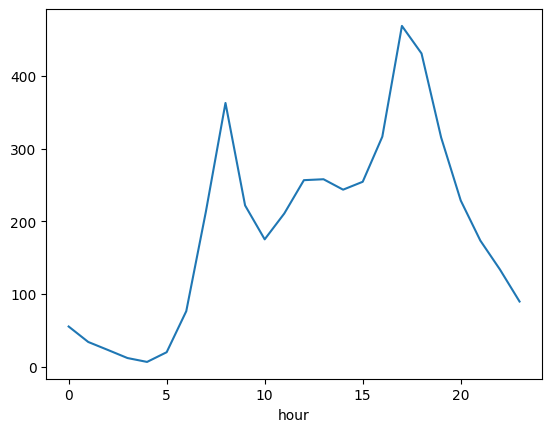

In [8]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

<Axes: xlabel='hour'>

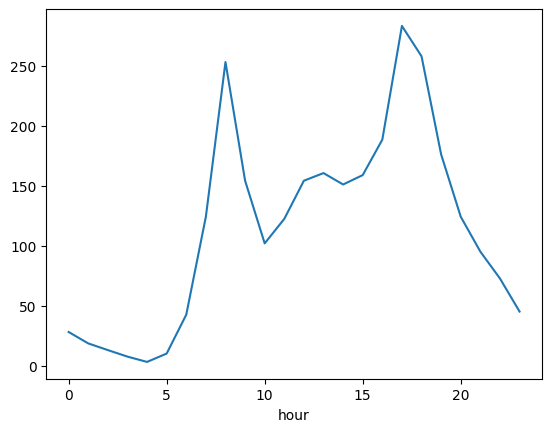

In [9]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes["season"] == 1].groupby("hour").total.mean().plot()

Al comparar el comportamiento del promedio de arrendamientos de bicicletas por hora en invierno (season = 1), se puede detallar que se mantiene un comportamiento similar al promedio de las cuatro temporadas, en este caso, la diferencia entre los valores promedio alcanzados a las 8 y el máximo promedio de las 17 es menor. Asimismo, en general, en esta temporada se alcanzan menores valores promedio de arrendamientos de bicicletas a lo largo del día.

<Axes: xlabel='hour'>

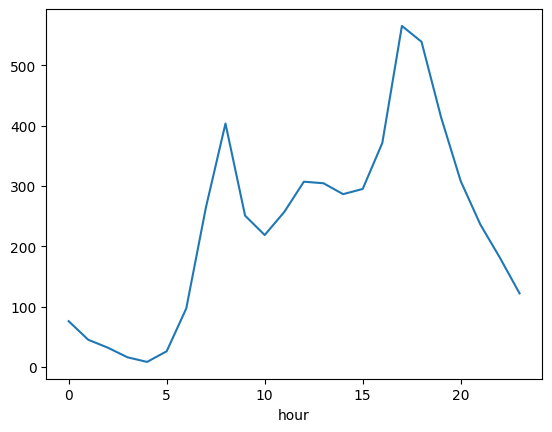

In [10]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes["season"] == 3].groupby("hour").total.mean().plot()

En este caso, al analizar el comportamiento del promedio de arrendamientos de bicicletas por hora en verano (season = 3), se observa que se mantienen los dos picos principales de demanda: el primero alrededor de la hora 8 y el máximo en la hora 17. Sin embargo, a diferencia de lo observado en invierno y en el promedio general de las temporadas, la diferencia entre estos dos picos es mayor.

Asimismo, se evidencian valores promedio más altos a lo largo de todo el día, especialmente en las horas de mayor actividad. En particular, el pico de las 8 supera los 400 arrendamientos promedio, valor que ya es cercano al máximo observado en el promedio general, mientras que el pico máximo en la hora 17 supera los 500.


### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [11]:
# Celda 3
X = bikes[["hour","season"]]
y = bikes["total"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17 )
modeloRL = LinearRegression()
modeloRL.fit(X_train,y_train)
print("Coeficientes:", modeloRL.coef_)
print("Intercepto:",   modeloRL.intercept_)

Coeficientes: [10.25377622 26.28730154]
Intercepto: 5.093536696389947


In [12]:
# Celda 3.1
#Se crean las variables dummies dado que season es categorica
season = pd.get_dummies(bikes['season'], prefix='season', drop_first=True)
X = pd.concat([bikes[['hour']], season], axis=1)
y = bikes["total"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17 )
modeloRL = LinearRegression()
modeloRL.fit(X_train,y_train)
print(season.columns)
print("Coeficientes:", modeloRL.coef_)
print("Intercepto:",   modeloRL.intercept_)

y_RL = modeloRL.predict(X_test)

mse_RL = (y_test - y_RL) ** 2
rmse_RL = np.sqrt(mse_RL.mean())
mae_RL  = np.abs(y_test - y_RL).mean()


Index(['season_2', 'season_3', 'season_4'], dtype='object')
Coeficientes: [ 10.27910374  97.15731165 119.39923874  80.64151203]
Intercepto: -3.7142421391306755


Comenzando por la variable hora, se tiene un coeficiente de 10.28, es decir, que al aumentar en una hora, la cantidad de bicicletas que se rentan aumenta en 10.28 unidades. El principal problema con la regresión lineal en este caso es que, al asumir una relación lineal, se pierden las caídas que se podían observar a lo largo del día: después de las 8:00 y después de las 18:00, donde disminuía la cantidad de bicicletas rentadas. Por lo tanto, se pierde poder predictivo en ciertos rangos horarios donde no se presenta la tendencia de crecimiento que sugiere el coeficiente de regresión.

En el caso de la variable temporada (season), al usar regresión lineal se está asumiendo un orden entre las temporadas, donde otoño (season = 4) es numéricamente mayor que invierno (season = 1). El coeficiente obtenido indica que al aumentar en una unidad la temporada, la cantidad de bicicletas arrendadas aumenta en 26.29 unidades. El problema de usar regresión lineal en este caso es que no se considera que las temporadas con mayor demanda son las intermedias: verano (season = 3) y primavera (season = 2). 

Una forma de solucionar el problema es aplicando la creación de variables "dummies", como se puede observar en la celda 3.1, donde los coeficientes de cada una de las temporadas ya muestran de mejor forma la relación que se había observado en las gráficas, donde el de verano (season = 3) es el de mayor valor, seguido por primavera (season = 2). En este caso, el de invierno ve su efecto reflejado en el cambio del intercepto que ahora es negativo.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [13]:
# Celda 4
#Funcion (mse)
def mse(y):
    if y.shape[0] == 0:
        return 0
    else:
        return np.mean((y - y.mean())**2)
# Reduccion del mse
def reduccion_mse(X_col, y, split):
    
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    
    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)
    
    reduccion_mse_ =  mse_y - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)

    return reduccion_mse_
# Definición de la función best_split para calcular cuál es la mejor variable y punto de cortepara hacer la bifurcación del árbol
def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    
    best_split = [0, 0, 0]  # j, split, gain
    
    # Para todas las varibles 
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        # Para cada partición
        for split in splits:
            gain = reduccion_mse(X.iloc[:, j], y, split)
                        
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split
    
# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, num_pct=10, split_counter=None, min_splits=5, max_depth=None):  
    
    if split_counter is None:
        split_counter = [0]
        
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[:1].values[0], level=level, split=-1, n_samples=1, gain=0)
        return tree
    
    j, split, gain = best_split(X, y, num_pct)
    
    y_pred =y.mean()
   
    
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    
    enough_splits = split_counter[0] >= min_splits 
    if gain < min_gain and enough_splits:
        return tree
    if max_depth is not None and level >= max_depth and enough_splits:  # ← criterio de parada max_depth
        return tree
     
    split_counter[0] += 1
   
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain, num_pct,
                           split_counter, min_splits, max_depth) 
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain, num_pct,
                           split_counter, min_splits, max_depth)  
    
    return tree

def predecir_arbol(tree,X):
    predicciones = []
    for i in range(X.shape[0]):
        nodo = tree
        while nodo['split'] != -1:
            j, split_val = nodo['split']
            if X.iloc[i, j] < split_val:
                nodo = nodo['sl']
            else:
                nodo = nodo['sr']
        predicciones.append(nodo['y_pred'])
    return np.array(predicciones)


In [14]:
X = bikes[["hour","season"]]
y = bikes["total"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17 )

tree = tree_grow(X_train, y_train, level=0,max_depth = 3,min_splits=5,num_pct=25)
tree

{'y_pred': np.float64(189.601312335958),
 'level': 0,
 'split': [0, np.float64(7.0)],
 'n_samples': 7620,
 'gain': np.float64(9941.721766083087),
 'sl': {'y_pred': np.float64(32.54773869346734),
  'level': 1,
  'split': [0, np.float64(6.0)],
  'n_samples': 2189,
  'gain': np.float64(344.9837563650008),
  'sl': {'y_pred': np.float64(24.890432923570284),
   'level': 2,
   'split': [0, np.float64(2.0)],
   'n_samples': 1871,
   'gain': np.float64(191.60783449237488),
   'sl': {'y_pred': np.float64(44.22555205047318),
    'level': 3,
    'split': [1, np.float64(2.0)],
    'n_samples': 634,
    'gain': np.float64(132.57572090450526),
    'sl': {'y_pred': np.float64(24.07051282051282),
     'level': 4,
     'split': [0, np.float64(1.0)],
     'n_samples': 156,
     'gain': np.float64(14.739440054154215),
     'sl': {'y_pred': np.float64(27.8125),
      'level': 5,
      'split': -1,
      'n_samples': 80,
      'gain': 0},
     'sr': {'y_pred': np.float64(20.13157894736842),
      'level': 5

In [15]:
y_arbol_manual = predecir_arbol(tree, X_test)
rmse = np.sqrt(np.mean((y_test - y_arbol_manual)**2))
MAE =  np.mean(np.abs(y_test - y_arbol_manual))
print(f"RMSE: {rmse:.2f}\nMAE:   {MAE:.2f}")

RMSE: 135.00
MAE:   91.36


### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [16]:
X = bikes[["hour","season"]]
y = bikes["total"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17 )
resultados = []
for depth in range(1,11):
    for min_samples in  range(5,35,5):
        arbol = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_split=min_samples,
            min_samples_leaf=5,
            random_state=17
        )
        mae_cv = -cross_val_score(arbol, X_train, y_train, cv=10, scoring='neg_mean_absolute_error').mean()
        resultados.append({
            'max_depth': depth,
            'min_samples_split': min_samples,
            'MAE': mae_cv
        })
resultados = pd.DataFrame(resultados)
pd.set_option('display.max_rows', None)
print(resultados.sort_values('MAE'))

    max_depth  min_samples_split         MAE
46          8                 25   76.586867
47          8                 30   76.586867
43          8                 10   76.586867
42          8                  5   76.586867
45          8                 20   76.586867
44          8                 15   76.586867
48          9                  5   76.598027
49          9                 10   76.598027
52          9                 25   76.598027
53          9                 30   76.598027
50          9                 15   76.598027
51          9                 20   76.598027
56         10                 15   76.611074
57         10                 20   76.611074
54         10                  5   76.611074
55         10                 10   76.611074
59         10                 30   76.611074
58         10                 25   76.611074
36          7                  5   76.665253
37          7                 10   76.665253
39          7                 20   76.665253
38        

In [19]:
# Celda 5
# Se utiliza el max_depth y min_samples_split que minimiza el MAE
arbol = DecisionTreeRegressor(max_depth=8,min_samples_split=5,min_samples_leaf=5)

arbol.fit(X_train,y_train)
y_arbol2 = arbol.predict(X_test)

mse_arbol2 = (y_test - y_arbol2) ** 2
rmse_arbol2 = np.sqrt(mse_arbol2.mean())
mae_arbol2  = np.abs(y_test - y_arbol2).mean()


print(f"RMSE_Arbol: {rmse_arbol2:.2f}")
print(f"MAE_Arbol:  {mae_arbol2:.2f}")

#Ahora el resultado de la regresion lineal
print(f"RMSE_Regresion_Lineal: {rmse_RL:.2f}")
print(f"MAE_Regresion_Lineal:  {mae_RL:.2f}")

RMSE_Arbol: 115.51
MAE_Arbol:  77.82
RMSE_Regresion_Lineal: 162.77
MAE_Regresion_Lineal:  119.77


Al comparar los dos modelos utilizando el MAE como criterio, el árbol de decisión logra reducir el error pasando de 119.77 (regresión lineal) a 77.82. Esto indica que el árbol captura mejor las relaciones no lineales entre las variables, las cuales la regresión lineal no logra modelar adecuadamente, como es el caso del comportamiento de la variable hora, que como se observó gráficamente, presenta diferentes pendientes a lo largo del día.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [17]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [18]:
# Definición variable de interes y variables predictoras
X_2 = df.drop(['url', 'Popular'], axis=1)
y_2 = df['Popular']
y_2.mean()

np.float64(0.5)

In [19]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_2, y_2, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [20]:
# Celda 6
### Regresion Logistica
Rlogistic = LogisticRegression()
Rlogistic.fit(X_train2 , y_train2)
y_Rlogistic = Rlogistic.predict(X_test2)
VP_RL = ((y_Rlogistic == 1) & (y_test2==1)).sum()
VN_RL = ((y_Rlogistic == 0) & (y_test2==0)).sum()
FP_RL = ((y_Rlogistic == 1) & (y_test2==0)).sum()
FN_RL = ((y_Rlogistic == 0) & (y_test2==1)).sum()
accuracy_RL = (VP_RL + VN_RL) /(VP_RL + VN_RL + FP_RL + FN_RL)
precision_RL = VP_RL / (VP_RL + FP_RL)
recall_RL    = VP_RL / (VP_RL + FN_RL)
# F1
f1_RL = 2 * (precision_RL * recall_RL) / (precision_RL + recall_RL)
print("=" * 35)
print("    Regresión Logística")
print("=" * 35)
print(f"  Accuracy: {accuracy_RL:.4f}")
print(f"  F1-Score: {f1_RL:.4f}")
print("=" * 35)






    Regresión Logística
  Accuracy: 0.6147
  F1-Score: 0.6131


In [21]:
resultados = []
for depth in range(1, 10):
    for min_samples in range(1, 10,1):
            for min_samples_s in range(2, 10,1):
                arbol = DecisionTreeClassifier(   
                    max_depth=depth,
                    min_samples_split=min_samples_s,
                    min_samples_leaf=min_samples,
                    random_state=17
                    )
                accuracy_cv = cross_val_score(          
                arbol, X_train2, y_train2, 
                cv=10, 
                scoring='accuracy'                 
                ).mean()
                resultados.append({
                'max_depth':          depth,
                'min_samples_split':  min_samples_s,  
                'min_samples_leaf':   min_samples,     
                'Accuracy':           accuracy_cv    
            })
resultados = pd.DataFrame(resultados)
pd.set_option('display.max_rows', None)
print(resultados.sort_values('Accuracy', ascending=False))  

     max_depth  min_samples_split  min_samples_leaf  Accuracy
128          2                  2                 8  0.630889
129          2                  3                 8  0.630889
130          2                  4                 8  0.630889
131          2                  5                 8  0.630889
132          2                  6                 8  0.630889
133          2                  7                 8  0.630889
134          2                  8                 8  0.630889
135          2                  9                 8  0.630889
136          2                  2                 9  0.630889
137          2                  3                 9  0.630889
138          2                  4                 9  0.630889
139          2                  5                 9  0.630889
140          2                  6                 9  0.630889
141          2                  7                 9  0.630889
142          2                  8                 9  0.630889
143     

In [22]:
## Arbol con los parametros optimos del punto anterior
arbol_clas = DecisionTreeClassifier( max_depth=2,min_samples_split=2,min_samples_leaf=1)
arbol_clas.fit(X_train2, y_train2)
y_arbol_clas = arbol_clas.predict(X_test2)
VP_AC = ((y_arbol_clas == 1) & (y_test2==1)).sum()
VN_AC = ((y_arbol_clas == 0) & (y_test2==0)).sum()
FP_AC = ((y_arbol_clas == 1) & (y_test2==0)).sum()
FN_AC = ((y_arbol_clas == 0) & (y_test2==1)).sum()
accuracy_AC = (VP_AC + VN_AC) /(VP_AC + VN_AC + FP_AC + FN_AC)
precision_AC = VP_AC / (VP_AC + FP_AC)
recall_AC    = VP_AC / (VP_AC + FN_AC)
# F1
f1_AC = 2 * (precision_AC * recall_AC) / (precision_AC + recall_AC)
print("=" * 35)
print("    Árbol de Clasificación")
print("=" * 35)
print(f"  Accuracy: {accuracy_AC:.4f}")
print(f"  F1-Score: {f1_AC:.4f}")
print("=" * 35)



    Árbol de Clasificación
  Accuracy: 0.6453
  F1-Score: 0.6449


El árbol de clasificación supera a la regresión logística en ambas métricas, mejorando el accuracy de 0.6147 a 0.6453 y el F1-score de 0.6131 a 0.6449. Esto se puede deber a la naturaleza del árbol, que puede capturar relaciones no lineales e interacciones entre las variables que la regresión logística no puede modelar adecuadamente.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [23]:
# Celda 7
# Creacion de las 300 muestras de boostrap
n_estimators_7 = 300
np.random.seed(17)
n_samples_7 = X_train2.shape[0]
samples = [np.random.choice(a=n_samples_7, size=n_samples_7, replace=True) for _ in range(n_estimators_7)]


seeds = np.random.randint(1, 10000, size=n_estimators_7)
modelos_7 = {}
for i in range(n_estimators_7):
    if i < 100 :
        modelos_7[i] = DecisionTreeClassifier( max_depth=2, random_state=seeds[i])
        modelos_7[i].fit(X_train2.iloc[samples[i]], y_train2.iloc[samples[i]])
    elif i < 200:
        modelos_7[i] = DecisionTreeClassifier( min_samples_leaf=4, random_state=seeds[i])
        modelos_7[i].fit(X_train2.iloc[samples[i]], y_train2.iloc[samples[i]])
    else:
        modelos_7[i] = LogisticRegression(max_iter=1000,n_jobs=-1)
        modelos_7[i].fit(X_train2.iloc[samples[i]], y_train2.iloc[samples[i]])
y_pred_df_7 = pd.DataFrame(index=X_test2.index, columns=list(range(n_estimators_7)))
for i in range(n_estimators_7):
    y_pred_df_7.iloc[:, i] = modelos_7[i].predict(X_test2)



In [24]:
resultados_ensamblaje = []
for i in range(n_estimators_7):
    
    y_pred_i = y_pred_df_7.iloc[:, i]  # predicciones del modelo i
    
    VP = ((y_pred_i == 1) & (y_test2 == 1)).sum()
    VN = ((y_pred_i == 0) & (y_test2 == 0)).sum()
    FP = ((y_pred_i == 1) & (y_test2 == 0)).sum()
    FN = ((y_pred_i == 0) & (y_test2 == 1)).sum()
    
    precision = VP / (VP + FP)
    recall    = VP / (VP + FN)
    f1        = 2 * (precision * recall) / (precision + recall)
    accuracy  = (VP + VN) / (VP + VN + FP + FN)
    
    resultados_ensamblaje.append({
        'modelo':   i,
        'tipo':     'Árbol max_depth=2'   if i < 100 else
                    'Árbol min_samples_leaf=4' if i < 200 else
                    'Regresión Logística',
        'Accuracy': accuracy,
        'F1':       f1
    })

resultados_ensamblaje = pd.DataFrame(resultados_ensamblaje)

resumen = resultados_ensamblaje.dropna().groupby('tipo')[['Accuracy', 'F1']].mean()

print("=" * 45)
print(f"{'Subgrupo':<25} {'Accuracy':>8} {'F1':>8}")
print("=" * 45)
for tipo, row in resumen.iterrows():
    print(f"{tipo:<25} {row['Accuracy']:>8.4f} {row['F1']:>8.4f}")


y_ensamblaje_7 = (y_pred_df_7.sum(axis=1) >= (n_estimators_7 / 2)).astype(np.int64)

VP_E7 = ((y_ensamblaje_7 == 1) & (y_test2==1)).sum()
VN_E7 = ((y_ensamblaje_7 == 0) & (y_test2==0)).sum()
FP_E7 = ((y_ensamblaje_7 == 1) & (y_test2==0)).sum()
FN_E7 = ((y_ensamblaje_7 == 0) & (y_test2==1)).sum()
accuracy_E7 = (VP_E7 + VN_E7) /(VP_E7 + VN_E7 + FP_E7 + FN_E7)
precision_E7 = VP_E7 / (VP_E7 + FP_E7)
recall_E7    = VP_E7 / (VP_E7 + FN_E7)
# F1
f1_E7 = 2 * (precision_E7 * recall_E7) / (precision_E7 + recall_E7)
print("=" * 35)
print("    Modelo de ensamblajes")
print("=" * 35)
print(f"  Accuracy: {accuracy_E7:.4f}")
print(f"  F1-Score: {f1_E7:.4f}")
print("=" * 35)

Subgrupo                  Accuracy       F1
Regresión Logística         0.6141   0.6012
Árbol max_depth=2           0.6358   0.6266
Árbol min_samples_leaf=4    0.5657   0.5544
    Modelo de ensamblajes
  Accuracy: 0.6393
  F1-Score: 0.6225


En este caso, se puede observar que, en promedio, el mejor modelo individual es el árbol con max_depth=2 (Accuracy: 0.6358, F1: 0.6266), seguido por la regresión logística (0.6141, 0.6012) y, por último, el árbol con min_samples_leaf=4 (0.5657, 0.5544), que presenta el peor desempeño de los tres.

El ensamble por votación mayoritaria logra un Accuracy de 0.6393, superando el desempeño de cada uno de los modelos mencionados anteriormente. Por lo tanto, esta votación logra una pequeña mejora en la predicción del modelo.

En el caso del F1-Score, sí se observa que el modelo de votación mayoritaria tiene un peor desempeño que el del árbol con max_depth=2 (0.6266). Esto se puede deber a que el árbol con min_samples_leaf=4, al tener un desempeño significativamente menor, introduce votos de baja calidad que pueden afectar la precisión o el recall del modelo ensamblado.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [25]:
# Celda 8
samples_oob = []
for sample in samples:
    samples_oob.append(sorted(set(range(n_samples_7)) - set(sample)))

errors_7 = np.zeros(n_estimators_7)
for i in range(n_estimators_7):
    y_pred_7 = modelos_7[i].predict(X_train2.iloc[samples_oob[i]])
    errors_7[i] =  1 - (y_pred_7 == y_train2.iloc[samples_oob[i]]).sum() / len(samples_oob[i])

alpha_7 = (1 - errors_7) / (1 - errors_7).sum()

weighted_sum_7 = (y_pred_df_7 * alpha_7).sum(axis=1)

y_ponderada = (weighted_sum_7 >=0.5).astype(np.int64)

VP_E8 = ((y_ponderada == 1) & (y_test2 == 1)).sum()
VN_E8 = ((y_ponderada == 0) & (y_test2 == 0)).sum()
FP_E8 = ((y_ponderada == 1) & (y_test2 == 0)).sum()
FN_E8 = ((y_ponderada == 0) & (y_test2 == 1)).sum()
accuracy_E8 = (VP_E8 + VN_E8) / (VP_E8 + VN_E8 + FP_E8 + FN_E8)
precision_E8 = VP_E8 / (VP_E8 + FP_E8)
recall_E8    = VP_E8 / (VP_E8 + FN_E8)
# F1
f1_E8 = 2 * (precision_E8 * recall_E8) / (precision_E8 + recall_E8)
print("=" * 35)
print("    Modelo de ensamblaje ponderado")
print("=" * 35)
print(f"  Accuracy: {accuracy_E8:.4f}")
print(f"  F1-Score: {f1_E8:.4f}")
print("=" * 35)

    Modelo de ensamblaje ponderado
  Accuracy: 0.6373
  F1-Score: 0.6196


En este caso el modelo de votación mayoritaria logra un mejor desempeño tanto en Accuracy como en F1-score en comparación con el modelo de votación ponderada. Aunque el desempeño del modelo ponderado es inferior, la diferencia no es muy significativa, por lo que es necesario revisar si, al utilizar modelos muy similares (se usaron dos árboles donde solo se cambió un parámetro), el modelo ponderado no se ve beneficiado.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

Al utilizar votación tanto ponderada como por mayorías, ambos modelos lograron mejores resultados a nivel de Accuracy que los obtenidos en promedio por cada uno de los subgrupos de modelos utilizados para las votaciones. Por lo tanto, el ensamblaje de votaciones ayuda a que los modelos cubran entre sí las falencias que puedan presentar.

Ahora, al observar el F1-score, se pueden evidenciar los problemas que pueden ocurrir con este tipo de ensamblajes, y es que un modelo con mal desempeño, en lugar de aportar, puede empeorar el resultado del ensamblaje.

#### Votación mayoritaria
##### Ventajas
* Los modelos de ensamblaje por votación mayoritaria son más simples de calcular y pueden aprovechar mejor la diversidad entre modelos, ya que todos aportan al mismo nivel en la elección del resultado.
##### Desventajas
* Si hay presencia de modelos con muy malos desempeños, esto puede afectar en mayor medida el resultado de las votaciones.
* El modelo no distingue entre la calidad de los resultados, ya que una votación donde un modelo tiene, por ejemplo, un 55% de confianza es tratada igual que una donde tiene un 90%.
#### Votación ponderada
##### Ventajas
* Los modelos de ensamblaje por votación ponderada reducen el impacto que pueden tener modelos con desempeños bajos.
* Se puede optimizar dependiendo de la metrica que se desea maximizar o minimizar. 
##### Desventajas
* Dependen de la forma en que se calculan los pesos para la ponderación.
* Pueden sobreajustar o incorporar información redundante si los modelos utilizados no son suficientemente diferentes entre sí.
